## Hw 1b: Experimental Analysis of a Shallow Neural Network

Instructions: see `hw_1b.md`. All training/evaluation logic is implemented in
`training_utils.py` (`get_model`, `train_model`, `valid_metrics`, `apply_augmentations`,
`show_batch`); this notebook only calls those functions and reports results.

In [1]:
# import pytorch libraries
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from training_utils import get_model, train_model, valid_metrics, apply_augmentations, show_batch

### Load the data and pick a validation set
Same loading as Part 1a. The first 10,000 examples of the training set are the
validation set; the remaining 50,000 are used for training.

In [2]:
train_df = pd.read_csv("fashion_mnist/fashion-mnist_train.csv")
test_df = pd.read_csv("fashion_mnist/fashion-mnist_test.csv")

labels_np = train_df.iloc[:, 0].astype(np.int64).values.copy()
images_np = train_df.iloc[:, 1:].astype(np.float32).values.copy()
test_labels_np = test_df.iloc[:, 0].astype(np.int64).values.copy()
test_images_np = test_df.iloc[:, 1:].astype(np.float32).values.copy()

X_all = torch.tensor(images_np, dtype=torch.float32) / 255.0
Y_all = torch.tensor(labels_np, dtype=torch.long)

X_valid, Y_valid = X_all[:10000], Y_all[:10000]
X_train, Y_train = X_all[10000:], Y_all[10000:]

X_train.shape, X_valid.shape

(torch.Size([50000, 784]), torch.Size([10000, 784]))

### 2. Learning Rate Selection
2-layer network, hidden size 50, ReLU, Adam, 500 epochs. The model is reinitialized
from scratch for each learning rate.

In [3]:
learning_rates = [1, 0.1, 0.01, 0.001, 0.0001, 0.00001]

lr_results = []
for lr in learning_rates:
    model = get_model(hidden_size=50)
    train_loss = train_model(model, X_train, Y_train, learning_rate=lr, epochs=500)
    valid_loss, valid_acc = valid_metrics(model, X_valid, Y_valid)
    lr_results.append({"learning_rate": lr, "train_loss": train_loss,
                        "valid_loss": valid_loss, "valid_acc": valid_acc})

lr_df = pd.DataFrame(lr_results)
lr_df

,learning_rate,train_loss,valid_loss,valid_acc
0,1.00000,2.081151,2.278410,0.1711
1,0.10000,0.447362,0.518456,0.8367
2,0.01000,0.227797,0.367875,0.8790
3,0.00100,0.330775,0.368475,0.8732
4,0.00010,0.681676,0.684571,0.7850
5,0.00001,1.881764,1.878074,0.5404


Interpolate between the best two learning rates found above.

In [4]:
best_two = sorted(lr_df.nlargest(2, "valid_acc")["learning_rate"].tolist())
interpolated_lrs = list(np.linspace(best_two[0], best_two[1], 4))[1:-1]

for lr in interpolated_lrs:
    model = get_model(hidden_size=50)
    train_loss = train_model(model, X_train, Y_train, learning_rate=lr, epochs=500)
    valid_loss, valid_acc = valid_metrics(model, X_valid, Y_valid)
    lr_results.append({"learning_rate": lr, "train_loss": train_loss,
                        "valid_loss": valid_loss, "valid_acc": valid_acc})

lr_df = pd.DataFrame(lr_results).sort_values("learning_rate").reset_index(drop=True)
best_lr = lr_df.loc[lr_df["valid_acc"].idxmax(), "learning_rate"]
print("best learning rate:", best_lr)
lr_df

best learning rate: 0.01


,learning_rate,train_loss,valid_loss,valid_acc
0,0.00001,1.881764,1.878074,0.5404
1,0.00010,0.681676,0.684571,0.7850
2,0.00100,0.330775,0.368475,0.8732
3,0.00400,0.275763,0.364671,0.8748
4,0.00700,0.281542,0.358000,0.8741
5,0.01000,0.227797,0.367875,0.8790
6,0.10000,0.447362,0.518456,0.8367
7,1.00000,2.081151,2.278410,0.1711


### 3. Effect of Hidden Layer Size
Fix the learning rate to the best value found above.

In [5]:
hidden_sizes = [10, 50, 100, 300, 1000, 2000]

hidden_results = []
for h in hidden_sizes:
    model = get_model(hidden_size=h)
    train_loss = train_model(model, X_train, Y_train, learning_rate=best_lr, epochs=500)
    valid_loss, valid_acc = valid_metrics(model, X_valid, Y_valid)
    hidden_results.append({"hidden_size": h, "train_loss": train_loss,
                            "valid_loss": valid_loss, "valid_acc": valid_acc})

hidden_df = pd.DataFrame(hidden_results)
best_hidden = int(hidden_df.loc[hidden_df["valid_acc"].idxmax(), "hidden_size"])
print("best hidden size:", best_hidden)
hidden_df

best hidden size: 2000


,hidden_size,train_loss,valid_loss,valid_acc
0,10,0.406997,0.458531,0.8427
1,50,0.219595,0.360264,0.8802
2,100,0.185829,0.335188,0.8849
3,300,0.143631,0.391313,0.8838
4,1000,0.097014,0.493345,0.8712
5,2000,0.067396,0.450773,0.8873


### 4. Visualize Transformed Images

level=mild (top row: original, bottom row: augmented)


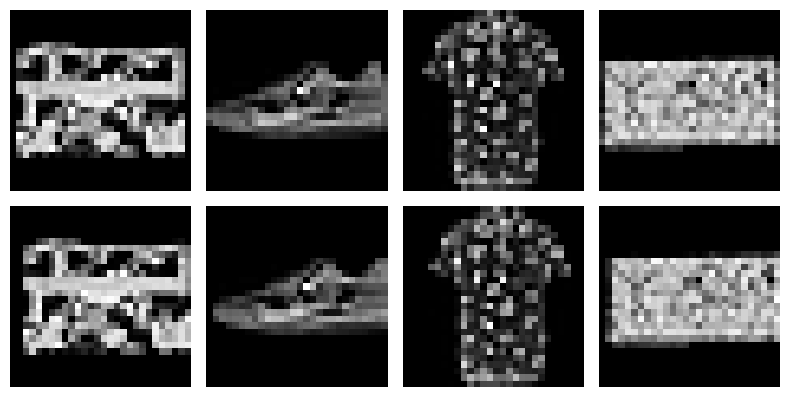

level=moderate (top row: original, bottom row: augmented)


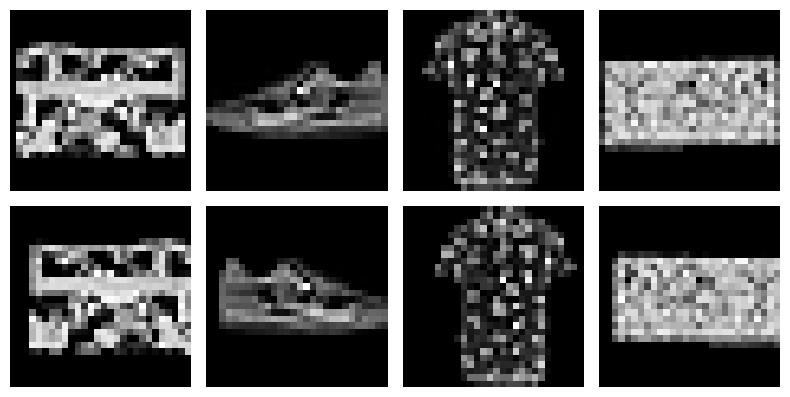

level=aggressive (top row: original, bottom row: augmented)


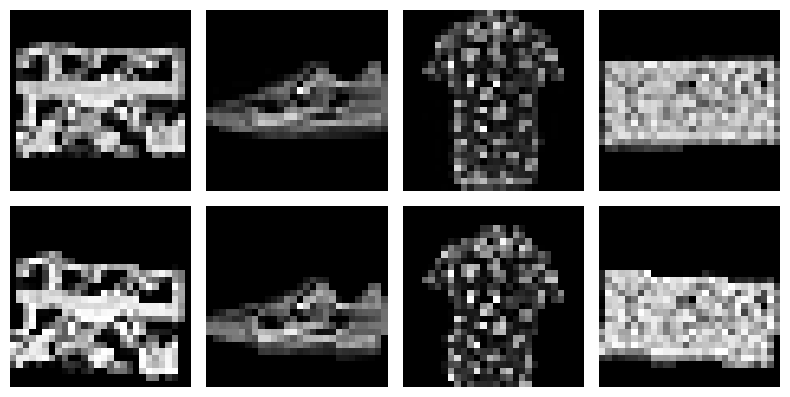

In [6]:
sample_imgs = X_train[:4]

for level in ["mild", "moderate", "aggressive"]:
    augmented = apply_augmentations(sample_imgs, level=level)
    combined = torch.cat([sample_imgs, augmented], dim=0).reshape(-1, 28, 28)
    print(f"level={level} (top row: original, bottom row: augmented)")
    show_batch(combined)

### 5. Effect of Data Augmentation
Using the best learning rate and best hidden size found above.

In [7]:
aug_levels = [None, "mild", "moderate", "aggressive"]

aug_results = []
for level in aug_levels:
    model = get_model(hidden_size=best_hidden)
    train_loss = train_model(model, X_train, Y_train, learning_rate=best_lr, epochs=500, level=level)
    valid_loss, valid_acc = valid_metrics(model, X_valid, Y_valid)
    aug_results.append({"augmentation": level or "baseline", "train_loss": train_loss,
                         "valid_loss": valid_loss, "valid_acc": valid_acc})

aug_df = pd.DataFrame(aug_results)
aug_df

,augmentation,train_loss,valid_loss,valid_acc
0,baseline,0.048141,0.464591,0.8896
1,mild,0.506174,0.523690,0.7988
2,moderate,0.684102,0.684839,0.7342
3,aggressive,0.817441,0.737847,0.7218
